Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [1]:
NAME = "Rhugved Bhojane"
COLLABORATORS = "Rhugved Bhojane"

---

# Problem description

To a large degree, financial data has traditionally been numeric in format.

But in recent years, non-numeric formats like image, text and audio have been introduced.  

Private companies have satellites orbiting the Earth taking photos and offering them to customers.  A financial analyst might be able to extract information from these photos that could aid in the prediction of the future price of a stock

- Approximate number of customers visiting each store: count number of cars in parking lot
- Approximate activity in a factory by counting number of supplier trucks arriving and number of delivery trucks leaving
- Approximate demand for a commodity at each location: count cargo ships traveling between ports

In this assignment, we will attempt to recognize ships in satellite photos.
This would be a first step toward
counting.

As in any other domain: specific knowledge of the problem area will make you a better analyst.

For this assignment, we will ignore domain-specific information and just try to use a labeled training set (photo plus a binary indicator for whether a ship is present/absent in the photo), assuming that the labels are perfect.



## Goal: 

In this notebook, you will need to create a model in `TensorFlow/Keras` to classify satellite photos.
- The features are images: 3 dimensional collection of pixels
  - 2 spatial dimensions
  - 1 dimension with 3 features for different parts of the color spectrum: Red, Green, Blue
- The labels are either 1 (ship is present) or 0 (ship is not present)

There are two notebook files in this assignment:
- The one you are viewing now: First and only notebook you need to work on. 
    - Train your models here
    - There are cells that will save your models to a file
- **`Model_test.ipynb`**:
    - PLEASE IGNORE    

You will create several Keras `Sequential` models, of increasing complexity
- A model that implements only a Classification Head (no transformations other than perhaps rearranging the image)
- A model that adds a Dense layer before the head
- (Later assignment) A model that adds Convolutional layers before the Head

## Learning objectives
- Learn how to construct Neural Networks using Keras Sequential model
- Appreciate how layer choices impact number of weights

# Imports modules

In [2]:
## Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

import os
import math

%matplotlib inline


## Import tensorflow and check the version
import tensorflow as tf
from tensorflow.keras.utils import plot_model

print("Running TensorFlow version ",tf.__version__)

# Parse tensorflow version
import re

version_match = re.match("([0-9]+)\.([0-9]+)", tf.__version__)
tf_major, tf_minor = int(version_match.group(1)) , int(version_match.group(2))
print("Version {v:d}, minor {m:d}".format(v=tf_major, m=tf_minor) )

<>:23: SyntaxWarning: invalid escape sequence '\.'
<>:23: SyntaxWarning: invalid escape sequence '\.'
/var/folders/t7/dpdxvfdj2l7g8rntzy7zzlm80000gn/T/ipykernel_36416/2888640679.py:23: SyntaxWarning: invalid escape sequence '\.'
  version_match = re.match("([0-9]+)\.([0-9]+)", tf.__version__)


Running TensorFlow version  2.18.0
Version 2, minor 18


# API for students

We have defined some utility routines in a file `helper.py`. There is a class named `Helper` in it.  

This will simplify problem solving

More importantly: it adds structure to your submission so that it may be easily graded

`helper = helper.Helper()`

- getData: Get a collection of labeled images, used as follows

  >`data, labels = helper.getData()`
- showData: Visualize labelled images, used as follows

  >`helper.showData(data, labels)`
- plot training results: Visualize training accuracy, loss and validation accuracy, loss

  >`helper.plotTrain(history, modelName)`, where history is the result of model training
- save model: save a model in `./models` directory

  >`helper.saveModel(model, modelName)`
- save history: save a model history in `./models` directory
  >`helper.saveHistory(history, modelName)`

In [3]:
# Load the helper module
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Reload all modules imported with %aimport
%reload_ext autoreload
%autoreload 1

# Import nn_helper module
import helper
%aimport helper


## You may pass an optional `data_dir` argument to the constructor `helper.Helper`
- if you have your data directory located somewhere other than the default location
- no need to provide an argument otherwise

For example:

        helper = helper.Helper(data_dir="./MyDataDir")

In [4]:
helper = helper.Helper()

# Get the data

The first step in our Recipe is Get the Data.

We have provided a utility method `getData` to simplify this for you

In [5]:
# Get the data
data, labels = helper.getData()
n_samples, width, height, channel = data.shape

print("Data shape: ", data.shape)
print("Labels shape: ", labels.shape)
print("Label values: ", np.unique(labels))



Data shape:  (4000, 80, 80, 3)
Labels shape:  (4000,)
Label values:  [0 1]


We will shuffle the examples before doing anything else.

This is usually a good idea
- Many datasets are naturally arranged in a *non-random* order, e.g., examples with the sample label grouped together
- You want to make sure that, when you split the examples into training and test examples, each split has a similar distribution of examples

In [6]:
# Shuffle the data first
data, labels = sklearn.utils.shuffle(data, labels, random_state=42)

## Have a look at the data

We will not go through all steps in the Recipe, nor in depth.

But here's a peek



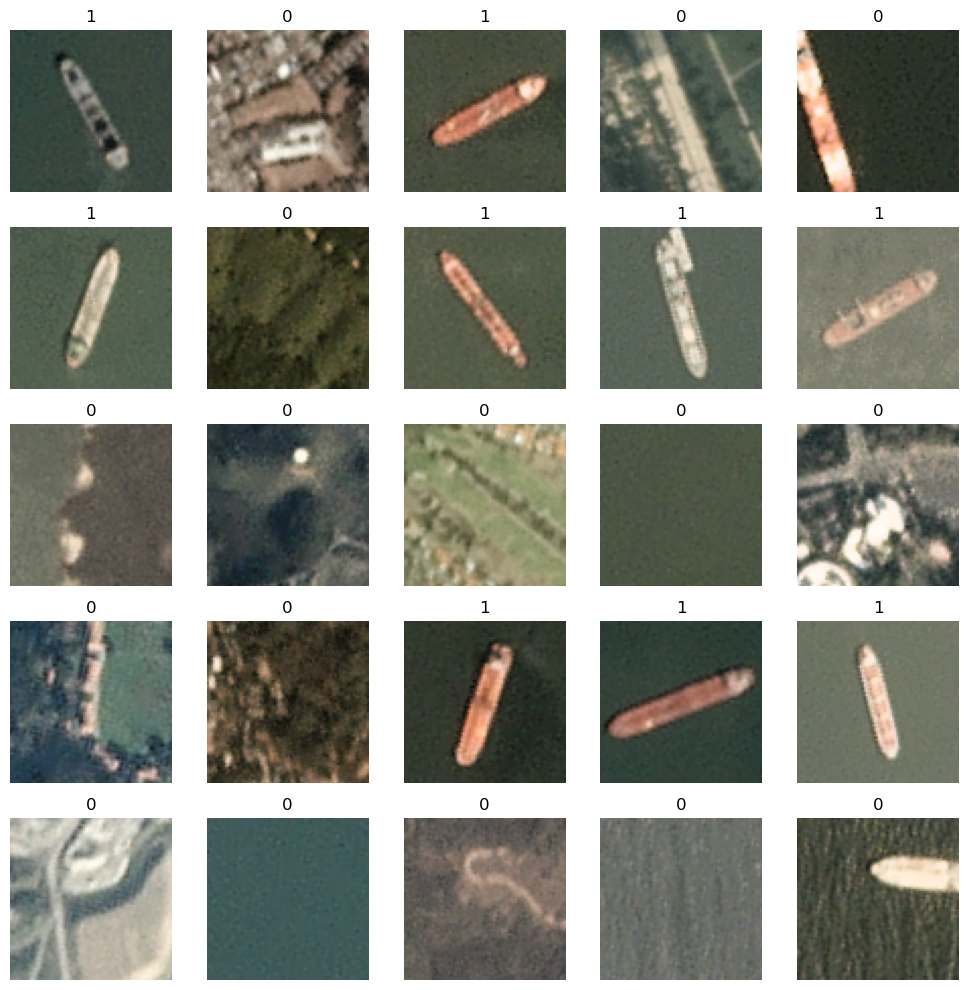

In [7]:
# Visualize the data samples
helper.showData(data[:25], labels[:25])

## Eliminate the color dimension

As a simplification, we will convert the image from color (RGB, with 3 "color" dimensions referred to as Red, Green and Blue) to gray scale.


In [8]:
print("Original shape of data: ", data.shape)

w = (.299, .587, .114)
data_bw = np.sum(data *w, axis=3)

print("New shape of data: ", data_bw.shape)

data_orig = data.copy()

Original shape of data:  (4000, 80, 80, 3)
New shape of data:  (4000, 80, 80)


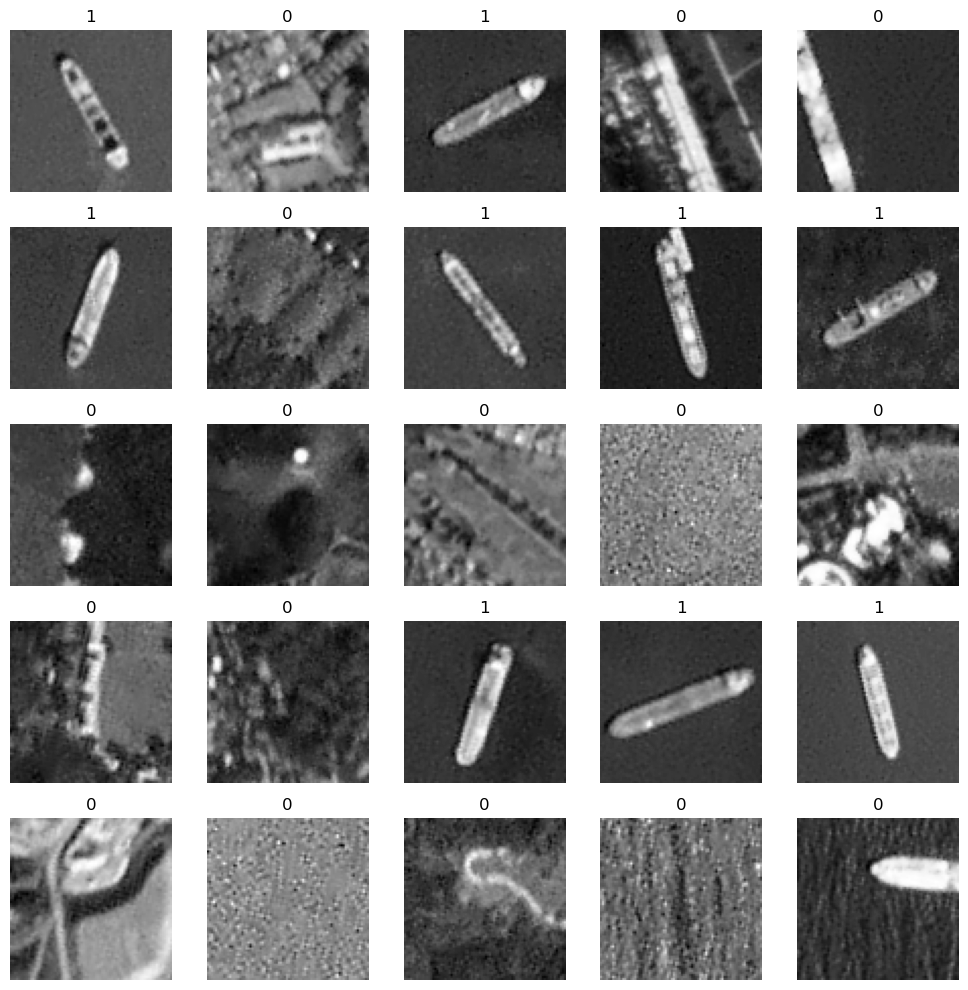

In [9]:
# Visualize the data samples
helper.showData(data_bw[:25], labels[:25], cmap="gray")

## Have  look at the data: Examine the image/label pairs

Rather than viewing the examples in random order, let's group them by label.

Perhaps we will learn something about the characteristics of images that contain ships.

We have loaded and shuffled our dataset, now we will take a look at image/label pairs. 

Feel free to explore the data using your own ideas and techniques.



In [10]:
# Inspect some data (images)
num_each_label = 10

for lab in np.unique(labels):
    # Fetch images with different labels
    X_lab, y_lab = data_bw[ labels == lab ], labels[ labels == lab]
    # Display images
    fig = helper.showData( X_lab[:num_each_label], [ str(label) for label in y_lab[:num_each_label] ], cmap="gray")
    _ = fig.suptitle("Label: "+  str(lab), fontsize=14)
    print("\n\n")


# Make sure the features are in the range [0,1]  

**Warm up exercise:** When we want to train image data, the first thing we usually need to do is scaling. 

Since the feature values in our image data are between 0 and 255, to make them between 0 and 1, we need to divide them by 255.  

We also need to consider how to represent our target values
- If there are more than 2 possible target values, One Hot Encoding may be appropriate
    - **Hint**: Lookup `tf.keras.utils.to_categorical`
- If there are only 2 possible targets with values 0 and 1 we can use these targets without further encoding

**Question**
- Set variable `X` to be our gray-scale examples (`data_bw`), but with values in the range [0,1]
- Set variable `y` to be the representation of our target values


In [11]:
# Scale the data
# Assign values for X, y
#  X: the array of features
#  y: the array of labels
# The length of X and y should be identical and equal to the length of data.
from tensorflow.keras.utils import to_categorical
X, y = np.array([]), np.array([])

# YOUR CODE HERE
X = data_bw / 255.0  
num_classes = len(np.unique(labels))
if num_classes > 2:
    y = to_categorical(labels, num_classes=num_classes)
else:
    y = labels
assert len(X) == len(y), "Mismatch in number of samples between X and y"
print('No Error')
#raise NotImplementedError()

No Error


In [12]:
# Check if your solution is right 

assert X.shape == (4000, 80, 80)
assert y.shape == (4000,)


# Split data into training data and testing data
To train and evaluate a model, we need to split the original dataset into
a training subset (in-sample) and a test subset (out of sample).

We will do this for you in the cell below.

**DO NOT** shuffle the data until after we have performed the split into train/test sets
- We want everyone to have the **identical** test set for grading
- Do not change this cell


In [13]:
# Split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# Save X_train, X_test, y_train, y_test for final testing
if not os.path.exists('./data'):
    os.mkdir('./data')
np.savez_compressed('./data/train_test_data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

# Create a model using only Classification, no data transformation (other than reshaping)

**Question:** You need to build a 1-layer (head layer only) network model with `tensorflow.keras`. Please name the head layer "dense_head".  

Set variable `model0` to be a Keras `Sequential` model object that implements your model.

**Hints:**
1. Since the dataset is 2-dimensional, you may want to use `Flatten()` in `tensorflow.keras.layers` to make your input data 1 dimensional. 
    - The `input shape` argument of the `Flatten()` layer should be the shape of a single example
2. The number of units in your head layer 
    - Depends on how you represented the target
    - It should be equal to the final dimension of  `y`

3. Activation function for the head layer: Since this is a classification problem
    - Use  `sigmoid` if your target's final dimension equals 1
    - Use  `softmax` if your target's final dimension is greater than 1

- A Dropout layer maybe helpful to prevent overfitting and accelerate your training process. 
    - If you want to use a Dropout layer, you can use `Dropout()`, which is in  `tensorflow.keras.layers`. 


In [14]:
# Get the number of unique labels
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
num_cases = np.unique(labels).shape[0]
if num_cases > 2:
    activation = "softmax"
    loss = 'categorical_crossentropy'
else:
    activation = "sigmoid"
    num_cases = 1
    loss = 'binary_crossentropy'
    
# Set model0 equal to a Keras Sequential model
model0 = Sequential([
    Flatten(input_shape=X.shape[1:]),  
    Dense(num_cases, activation=activation, name="dense_head")  
])
model0.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
# YOUR CODE HERE
#raise NotImplementedError()

model0.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

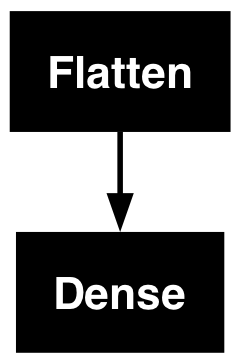

In [15]:
# We can plot our model here using plot_model()
plot_model(model0)

## Train model

**Question:**

Now that you have built your first model, you will compile and train it. The requirements are as follows:

- Split the **training** examples `X_train, y_train` again !
    - 80% will be used for training the model
    - 20% will be used as validation (out of sample) examples
    - Use `train_test_split()` from `sklearn` to perform this split
        -  Set the `random_state` parameter of `train_test_split()` to be 42

- Loss function: 
    - `binary_crossentropy` if your target is one-dimensional
    - `categorical_crossentropy`if your target is One Hot Encoded
- Metric: "accuracy"
- Use exactly 15  epochs for training
- Save your training results in a variable named `history0`
- Plot your training results using the`plotTrain` method described in the Student API above.


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7735 - loss: 0.4826 - val_accuracy: 0.8288 - val_loss: 0.3852
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.8491 - loss: 0.3757 - val_accuracy: 0.8238 - val_loss: 0.4292
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.8548 - loss: 0.3526 - val_accuracy: 0.8625 - val_loss: 0.3468
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.8668 - loss: 0.3363 - val_accuracy: 0.8487 - val_loss: 0.3615
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - accuracy: 0.8710 - loss: 0.3190 - val_accuracy: 0.8662 - val_loss: 0.3229
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step - accuracy: 0.8682 - loss: 0.3204 - val_accuracy: 0.8737 - val_loss: 0.3114
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.8740 - loss: 0.3019 - val_accuracy: 0.8600 - val_loss: 0.3294
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.8705 - loss: 0.2945 - va

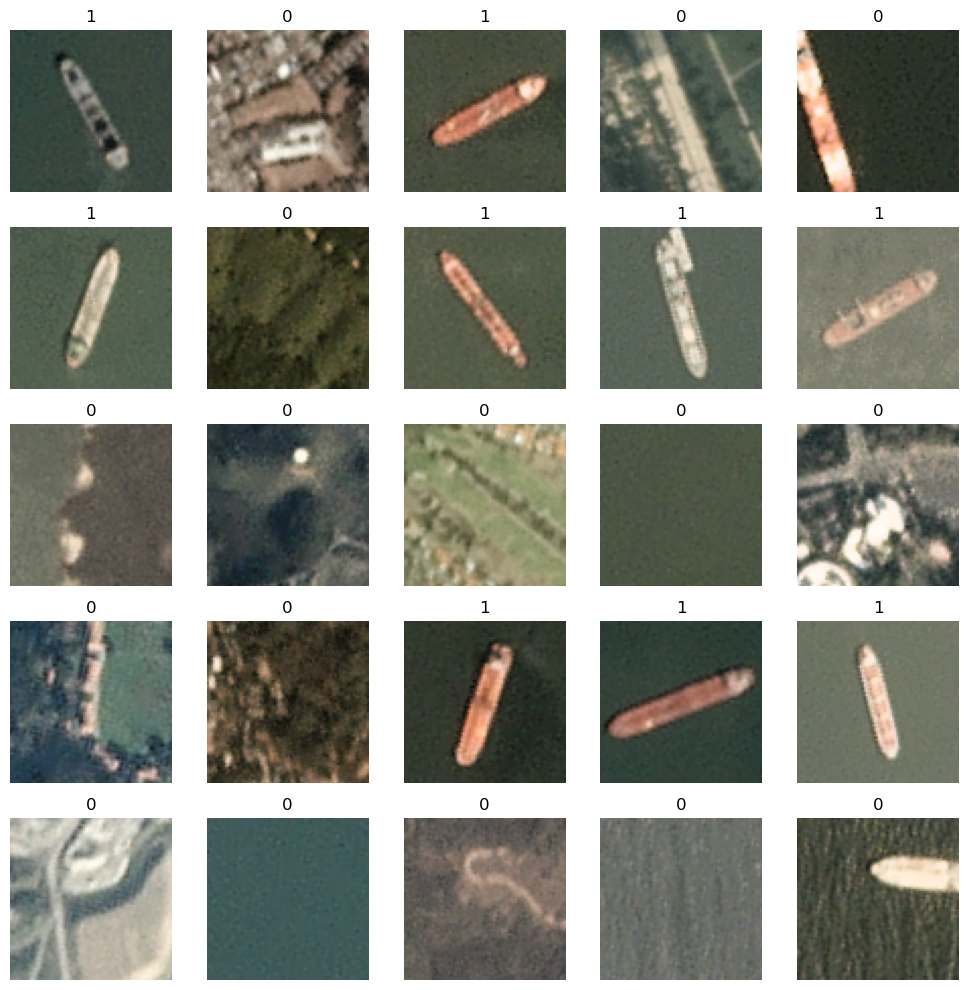

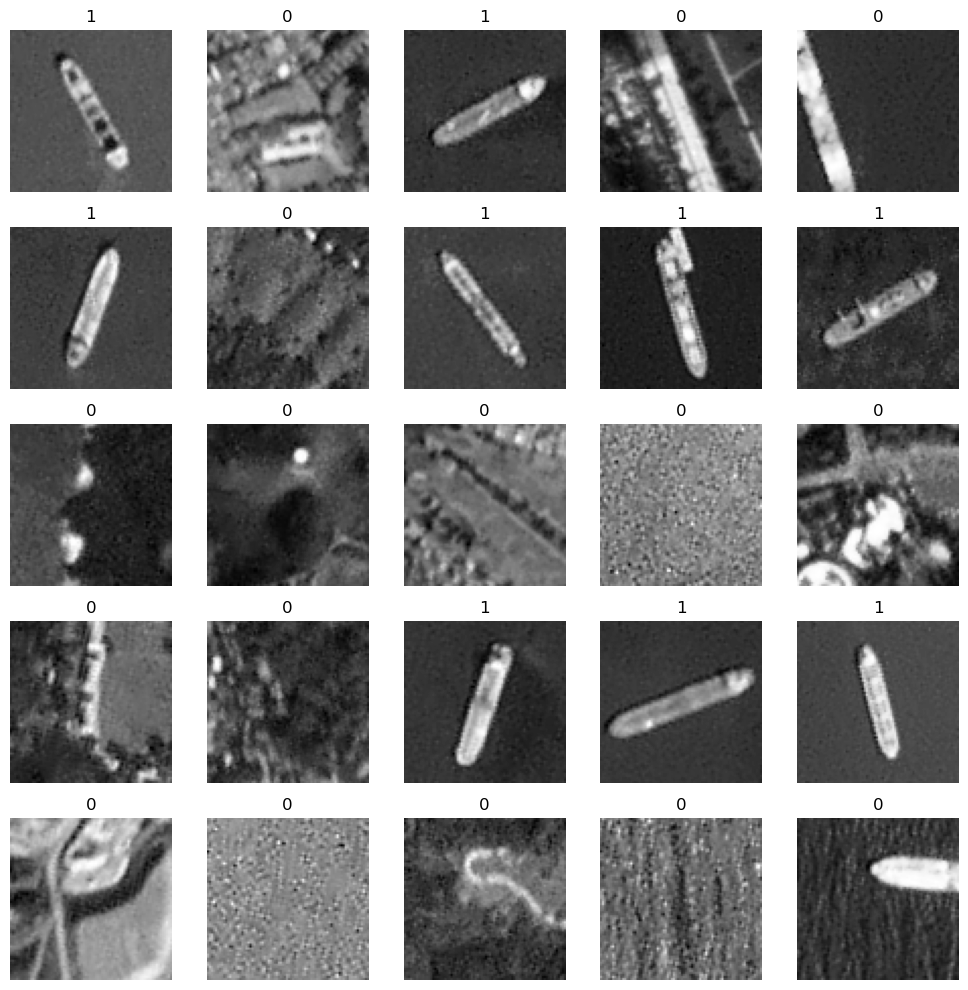

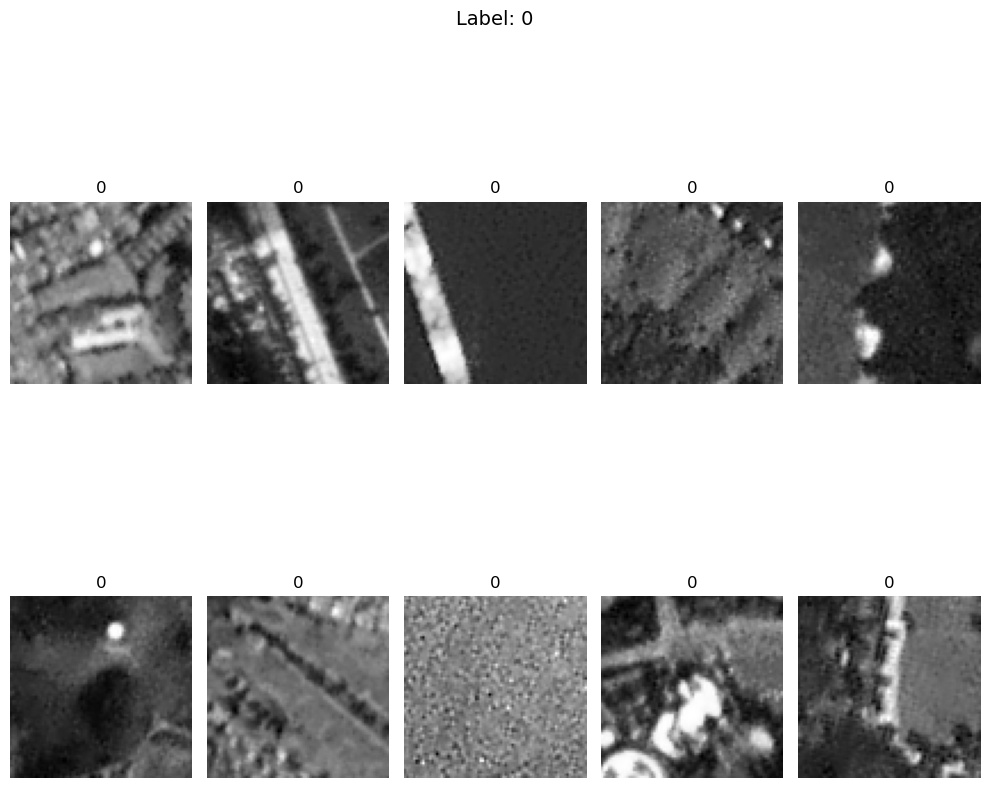

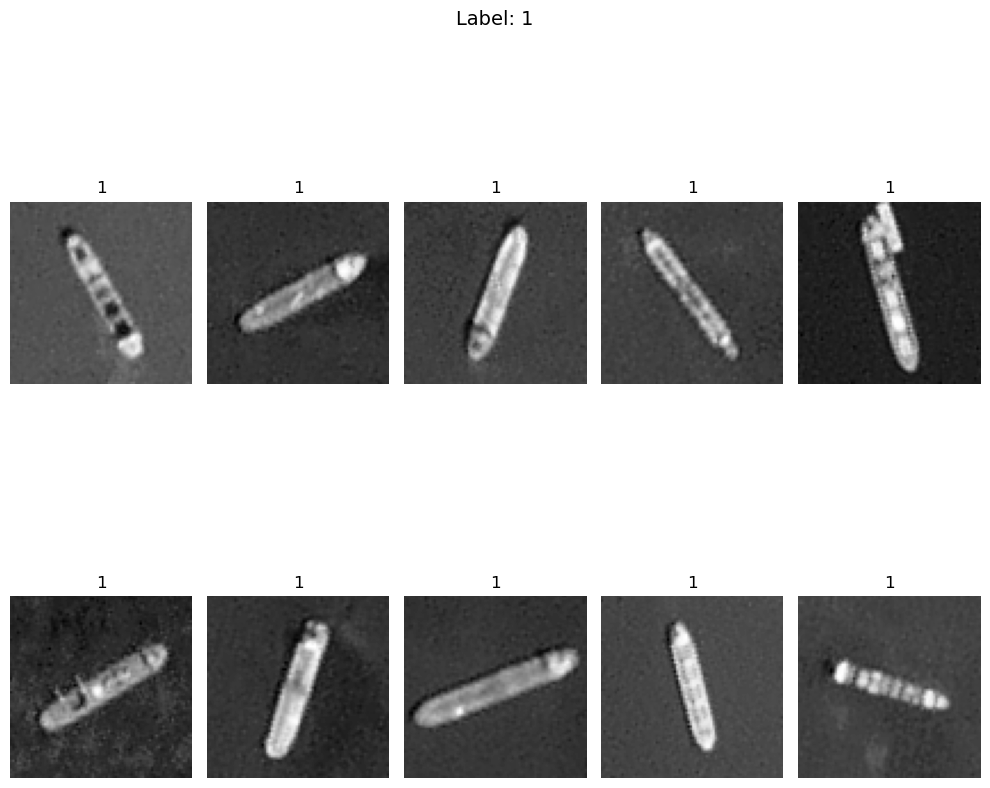

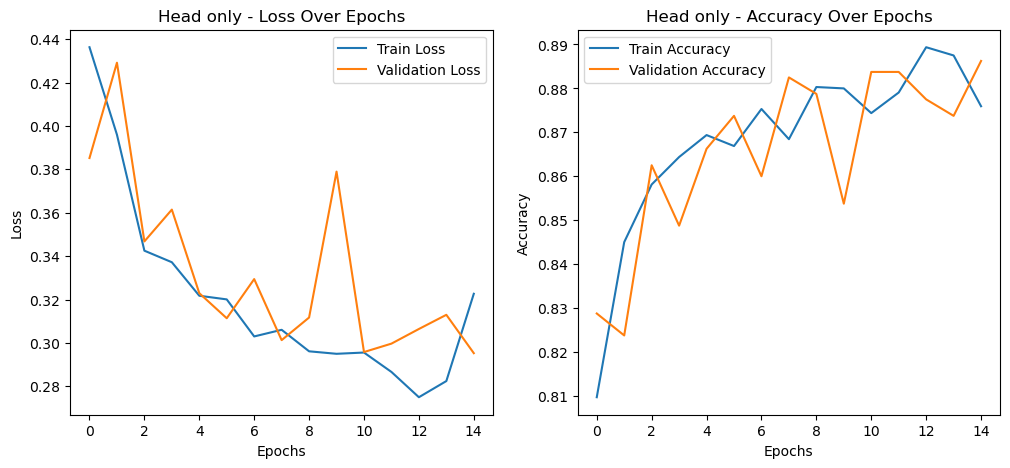

In [16]:
model_name0 = "Head only"

# YOUR CODE HERE

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

if y_train.ndim == 1 or y_train.shape[1] == 1:
    loss_function = 'binary_crossentropy'
else:
    loss_function = 'categorical_crossentropy'

model0.compile(optimizer='adam', loss=loss_function, metrics=['accuracy'])
history0 = model0.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,  
    verbose=1  
)


def plotTrain(history, model_name):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss Over Epochs')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy Over Epochs')
    plt.legend()
    
    plt.show()

plotTrain(history0, model_name0)

#raise NotImplementedError()

## How many weights in the model ?

**Question:** 

Calculate the number of parameters in your model.  

Set variable `num_parameters0` to be equal to the number of parameters in your model.

**Hint:** The model object may have a method to help you ! Remember that Jupyter can help you find the methods that an object implements.


In [17]:
# Set num_parameters0 equal to the number of weights in the model
num_parameters0 = model0.count_params()

# YOUR CODE HERE
#raise NotImplementedError()

print("Parameters number in model0: ", num_parameters0)

Parameters number in model0:  6401


## Evaluate the model

**Question:**

We have trained our model. We now need to  evaluate the model using the test dataset created in an earlier cell.

Please store the model score in a variable named `score0`.   

**Hint:** The model object has a method  `evaluate`.  Use that to compute the score.

In [18]:
score0 = model0.evaluate(X_val, y_val, verbose=1)

# YOUR CODE HERE
#raise NotImplementedError()

print("{n:s}: Test loss: {l:3.2f} / Test accuracy: {a:3.2f}".format(n=model_name0, l=score0[0], a=score0[1]))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8818 - loss: 0.3091 
Head only: Test loss: 0.30 / Test accuracy: 0.89


## Save the trained model0 and history0 for submission

Your fitted model can be saved for later use
- In general: so you can resume training at a later time
- In particular: to allow us to grade it !

Execute the following cell to save your model, which you will submit to us for grading.

In [19]:
helper.saveModel(model0, model_name0)
helper.saveHistory(history0, model_name0)

Directory models already exists, files will be over-written.
Model saved in ./models/Head only.keras; submit with your assignment.
Directory ./models/Head only already exists, files will be over-written.


**Question:**

Make sure that the saved model can be successfully restored.
- Set variable `model_loss` to the value of the loss parameter you used in the `compile` statement for your model
- Set variable `model_metrics` to the value of the metrics parameter you used in the `compile` statement for  your model

In [22]:
if y_train.ndim == 1 or y_train.shape[1] == 1:
    model_loss = 'binary_crossentropy'
else:
    model_loss = 'categorical_crossentropy'

model_metrics = ['accuracy']  

model_loaded = helper.loadModel(model_name0, loss=model_loss, metrics=model_metrics)

score_loaded = model_loaded.evaluate(X_test, y_test, verbose=0)

assert np.isclose(score_loaded[0], score0[0], atol=1e-6) and np.isclose(score_loaded[1], score0[1], atol=1e-6), \
    f"Mismatch detected: Original Loss={score0[0]}, Restored Loss={score_loaded[0]}, Original Accuracy={score0[1]}, Restored Accuracy={score_loaded[1]}"


AssertionError: Mismatch detected: Original Loss=0.29527032375335693, Restored Loss=0.30203762650489807, Original Accuracy=0.8862500190734863, Restored Accuracy=0.8824999928474426

# Create a new model with an additional Dense layer 

**Question:** 

We will add more layers to the original model0. 

- You need to add **AT LEAST ONE** Dense layer followed by an activation function (for example, ReLU)
    - You can add more layers if you like
    
- The number of units in your very **FIRST** Dense layer should be equal to the value of variable `num_features_1`, as set below.
    - Please name this Dense layer "dense_1" and the head layer "dense_head". 

**Hints:**
- Don't forget to flatten your input data!
- A Dropout layer maybe helpful to prevent overfitting and accelerate your training process. 
    - If you want to use a Dropout layer, you can use `Dropout()`, which is in  `tensorflow.keras.layers`. 

Hopefully your new model performs **better** than your first.

In [23]:
# Set model1 equal to a Keras Sequential model
num_features_1 = 32
model1 = Sequential([
    Flatten(input_shape=X.shape[1:]),  
    Dense(num_features_1, activation='relu', name="dense_1"),  
    Dropout(0.3),  
    Dense(num_cases, activation=activation, name="dense_head")  
])
model1.compile(optimizer='adam', loss=loss_function, metrics=['accuracy'])
# YOUR CODE HERE
#raise NotImplementedError()

model1.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │       204,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,865 (800.25 KB)

 Trainable params: 204,865 (800.25 KB)

 Non-trainable params: 0 (0.00 B)

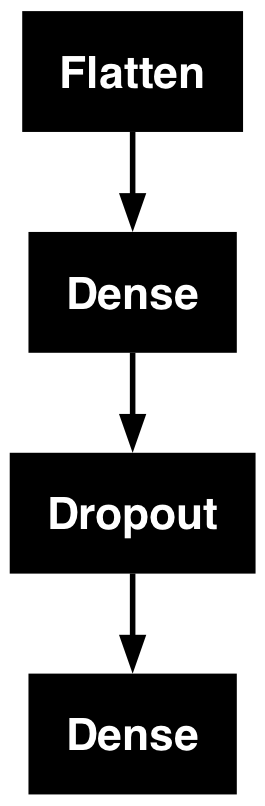

In [24]:
# Plot your model
plot_model(model1)

## Train your new model

**Question:**

Now that you have built your new model1,  you will compile and train model1. The requirements are as follows:

- Split the **training** examples `X_train, y_train` again !
    - 80% will be used for training the model
    - 20% will be used as validation (out of sample) examples
    - Use `train_test_split()` from `sklearn` to perform this split
        -  Set the `random_state` parameter of `train_test_split()` to be 42

- Loss function and Metric as per first model's instructions.
- Use exactly 15  epochs for training
- Save your training results in a variable named `history1`
- Plot your training results using the`plotTrain` method described in the Student API above.


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7011 - loss: 0.7303 - val_accuracy: 0.7563 - val_loss: 0.4465
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7506 - loss: 0.4739 - val_accuracy: 0.7563 - val_loss: 0.4362
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7511 - loss: 0.4389 - val_accuracy: 0.7563 - val_loss: 0.3987
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7480 - loss: 0.4432 - val_accuracy: 0.7563 - val_loss: 0.3834
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7378 - loss: 0.4285 - val_accuracy: 0.7563 - val_loss: 0.3858
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7553 - loss: 0.4069 - val_accuracy: 0.7563 - val_loss: 0.3881
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7537 - loss: 0.4256 - val_accuracy: 0.7563 - val_loss: 0.4401
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7475 - loss: 0.4431 - val_accuracy: 0.

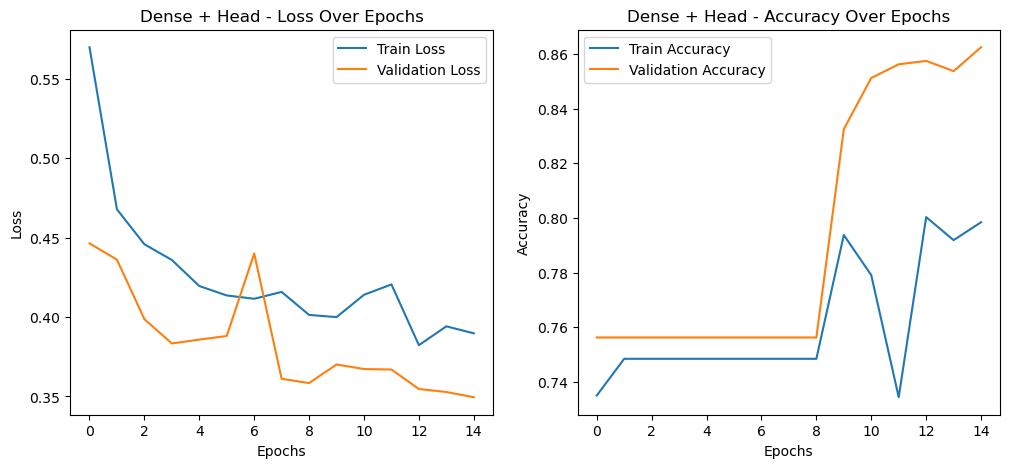

In [25]:
# Train the model using the API
model_name1 = "Dense + Head"
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,  
    verbose=1
)
def plotTrain(history, model_name):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss Over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy Over Epochs')
    plt.legend()
    
    plt.show()

plotTrain(history1, model_name1)

# YOUR CODE HERE
#raise NotImplementedError()

## How many weights in this model ?

**Question:** Calculate the number of parameters in your new model.  

Set variable `num_parameters1` to be equal to the number of parameters in your model.

In [26]:
# Set num_parameters1 equal to the number of weights in the model
num_parameters1 = model1.count_params()

# YOUR CODE HERE
#raise NotImplementedError()

print('Parameters number in model1:', num_parameters1)

Parameters number in model1: 204865


## Evaluate the model

**Question:**

Evaluate the new model using the test dataset. Please store the model score in a variable named `score1`.   

In [27]:
score1 = model1.evaluate(X_val,y_val,verbose=1)

# YOUR CODE HERE
#raise NotImplementedError()

print("{n:s}: Test loss: {l:3.2f} / Test accuracy: {a:3.2f}".format(n=model_name1, l=score1[0], a=score1[1]))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8555 - loss: 0.3425
Dense + Head: Test loss: 0.35 / Test accuracy: 0.86


Your new test score should be at least 0.8

# Save your trained model1 and history1

In [28]:
helper.saveModel(model1, model_name1)
helper.saveHistory(history1, model_name1)

Directory models already exists, files will be over-written.
Model saved in ./models/Dense + Head.keras; submit with your assignment.
Directory ./models/Dense + Head already exists, files will be over-written.


## Your own model (Optional)
Now you can build your own model using what you have learned from the course. Some ideas to try:
- Try more than one additional `Dense` layer 
- Change the number of units (features) of your `Dense` layers. 
- Add `Dropout` layers; vary the parameter 
- Change the activation function
- Change the classifier
- ...

Observe the effect of each change on the Loss and Accuracy.

- You may want to use early stopping in training
    - In order to stop training when model metrics *worsen* rather than *improve*


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

model = Sequential([
    Flatten(input_shape=X.shape[1:]),  
    Dense(128, activation='relu', kernel_regularizer=l2(0.01), name="dense_2"),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), name="dense_3"),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu', name="dense_4"),
    Dropout(0.2),
    
    Dense(num_cases, activation=activation, name="output_layer")
])

optimizer = Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64, callbacks=[early_stopping, reduce_lr])


Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7095 - loss: 3.6327 - val_accuracy: 0.7862 - val_loss: 2.7863 - learning_rate: 5.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8676 - loss: 2.4650 - val_accuracy: 0.8763 - val_loss: 2.0388 - learning_rate: 5.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8751 - loss: 1.7710 - val_accuracy: 0.8138 - val_loss: 1.5805 - learning_rate: 5.0000e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9057 - loss: 1.3049 - val_accuracy: 0.8963 - val_loss: 1.1765 - learning_rate: 5.0000e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8910 - loss: 1.0501 - val_accuracy: 0.8163 - val_loss: 1.1080 - learning_rate: 5.0000e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9245 - loss: 0.7950 - val_accuracy: 0.5063 - val_loss: 1.2628 - learning_rate: 5.0000e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9216 - loss: 0.65

In [30]:
score2 = model.evaluate(X_val,y_val,verbose=1) 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9214 - loss: 0.2718 


In [31]:
model_name00='Custom'

In [32]:
print("{n:s}: Test loss: {l:3.2f} / Test accuracy: {a:3.3f}".format(n=model_name00, l=score2[0], a=score2[1]))

Custom: Test loss: 0.25 / Test accuracy: 0.939


In [33]:
num_parameters2 = model.count_params()
print('Parameters number in model1:', num_parameters2)

Parameters number in model1: 830465


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9556 - loss: 0.2093 - val_accuracy: 0.9362 - val_loss: 0.2538 - learning_rate: 7.8125e-06
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9518 - loss: 0.2121 - val_accuracy: 0.9350 - val_loss: 0.2513 - learning_rate: 7.8125e-06
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9590 - loss: 0.2087 - val_accuracy: 0.9375 - val_loss: 0.2513 - learning_rate: 7.8125e-06
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9528 - loss: 0.2266 - val_accuracy: 0.9325 - val_loss: 0.2586 - learning_rate: 7.8125e-06
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9588 - loss: 0.1966 - val_accuracy: 0.9350 - val_loss: 0.2582 - learning_rate: 7.8125e-06
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9623 - loss: 0.2013 - val_accuracy: 0.9337 - val_loss: 0.2512 - learning_rate: 3.9063e-06
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9524 

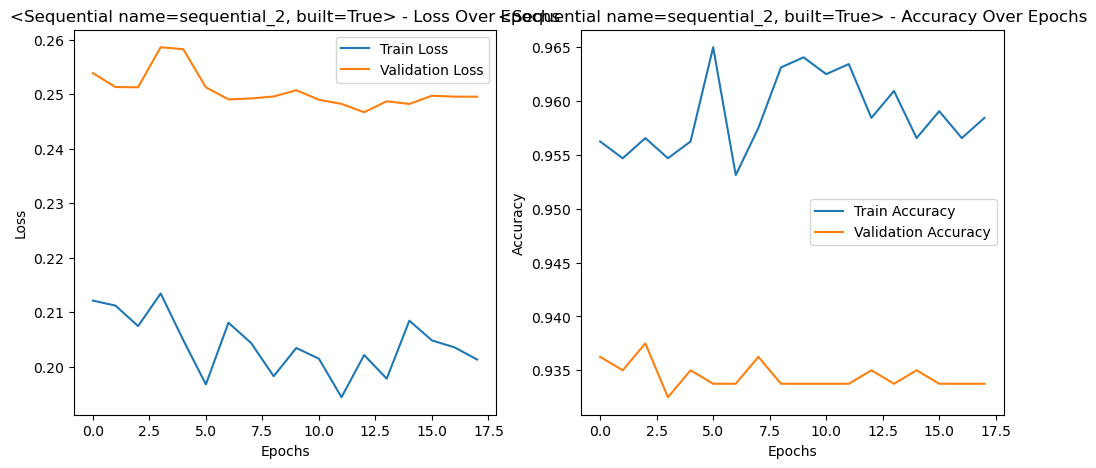

In [34]:
def plotTrain(history, model_name):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss Over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy Over Epochs')
    plt.legend()
    
    plt.show()
history5=model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64, callbacks=[early_stopping, reduce_lr])
plotTrain(history5, model)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted Label')

Text(70.72222222222221, 0.5, 'True Label')

Text(0.5, 1.0, 'Confusion Matrix')

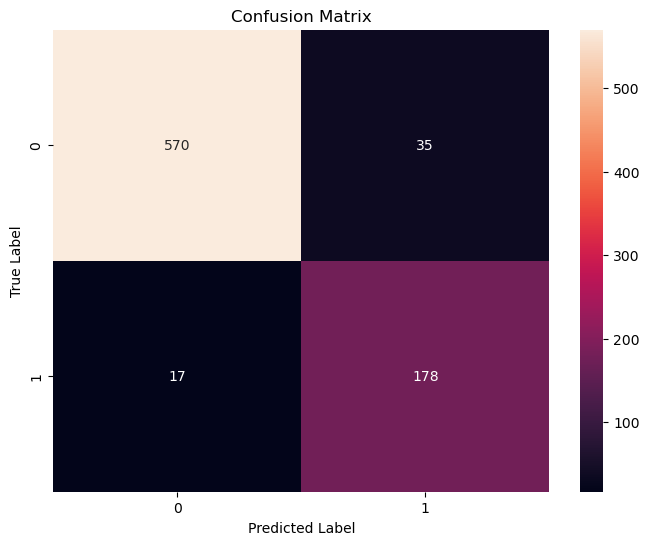

In [35]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_val)

if loss_function == 'binary_crossentropy':
    y_pred_classes = (y_pred > 0.5).astype(int).flatten()
    y_val_classes = y_val.astype(int).flatten()
else:  
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_val_classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', xticklabels=np.unique(y_val_classes), yticklabels=np.unique(y_val_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
